## `np.bincount()`

In [5]:
import numpy as np
import pandas as pd

In [2]:
np.bincount([0, 2, 4, 4, 3])

array([1, 0, 1, 1, 2])

## `spacy` for Lemmatization

In [4]:
# pip install spacy
# import spacy
# en_nlp = spacy.load('en')
# doc_spacy = en_nlp(u'This is my text')
# print([token.lemma_ for token in doc_spacy])

## `CountVectorizer` Options

In [8]:
from sklearn.feature_extraction.text import CountVectorizer

In [9]:
cv = CountVectorizer(max_features=2000)

## `sklearn.decomposition.LatentDirichletAllocation`

In [10]:
from sklearn.decomposition import LatentDirichletAllocation

## Likely Events

Suppose some event $e$ has a 98% chance of occurring. How many times would $e$ have to happen in a row before such a streak would be _unlikely_?

In [5]:
import math

In [15]:
math.log(0.5, 0.98)

34.309618491520645

35!

In [8]:
0.98**34

0.5031373679776306

In [9]:
0.98**35

0.493074620618078

## Birthday Paradox

Here's a similar sort of problem, sometimes called the "Birthday Paradox". It's unlikely for two people to have the same birthday, but how many people would I need to collect together before finding it likely that two of them have the same birthday?

To begin, let's make a choice about how to handle births on February 29. For simplicity's sake, we'll just treat that day like any other, and say that there are 366 days in a year. This will mean that we'll slightly *under*calculate the relevant probabilities here, but that's okay; we won't demand surgical precision.

Now one might suppose that I'd need to collect half of 366 -- 183 -- people together before making it likely that two would have the same birthday. But that's not how probabilities work!

As before we'll solve our problem by thinking about the probability that n people do not have the same birthday and then subtracting that from unity.

If I have only two people, the chance that they do not have the same birthday is
365 / 366.

In [1]:
365/366

0.9972677595628415

What if I have three people? Now this is where the current problem diverges a bit from the coin-flip example, because I now need to make sure that the third person's birthday is different *both* from the first person's *and* from the second person's. Thus the probability that no two of the three have the same birthday will be
(365 / 366) * (364 / 366).

In [2]:
365/366 * 364/366

0.9918182089641374

Well, once again the probabilities are certainly going down, but how do we find the number of people n where

1 - ((365 * ... * (366 - ((n-1)-1))) / 366^((n-1)-1)) > 0.5 but

1 - ((365 * ... * (366 - (n-1))) / 366^(n-1)) < 0.5? That is, the smallest number of people where no two people having a common birthday would actually be unlikely, despite the 99.7% chance that any two people don't have a common birthday? Our equation is in effect:

1 - ((365 * ... * (366 - (n-1))) / 366^(n-1)) = 0.5, which we can rewrite as:
1 - ((365! / (365-(n-1))!) / 366^(n-1)) = 0.5.

Let's graph it!

In [4]:
from matplotlib import pyplot as plt
from math import factorial as f

In [83]:
def func(n):
    from math import factorial as f
    minuend = n-1
    base = 1 / 366**minuend
    num = f(365)
    den = f(365-minuend)
    return 1 - base * (num / den)

In [84]:
n_func = np.vectorize(func)

In [88]:
X = np.arange(2, 51)

Y = n_func(X)

Experimenting with range() and np.arange()

In [63]:
Y = np.array([func(n) for n in range(2, 51)])

In [64]:
Y

array([0.00273224, 0.00818179, 0.01631145, 0.02706214, 0.04035364,
       0.05608555, 0.07413856, 0.09437597, 0.11664541, 0.14078078,
       0.16660431, 0.19392876, 0.22255971, 0.25229786, 0.28294139,
       0.31428821, 0.34613822, 0.37829535, 0.41056964, 0.44277895,
       0.47475065, 0.50632301, 0.53734643, 0.56768437, 0.59721412,
       0.62582733, 0.65343023, 0.67994376, 0.70530341, 0.72945887,
       0.75237356, 0.77402396, 0.79439884, 0.81349841, 0.83133326,
       0.84792343, 0.86329729, 0.87749047, 0.89054476, 0.90250708,
       0.91342842, 0.92336286, 0.93236668, 0.94049746, 0.94781335,
       0.95437233, 0.96023162, 0.96544714, 0.97007307])

In [65]:
n_func = np.vectorize(func)
Y = n_func(X)

In [66]:
Y

array([0.00273224, 0.00818179, 0.01631145, 0.02706214, 0.04035364,
       0.05608555, 0.07413856, 0.09437597, 0.11664541, 0.14078078,
       0.16660431, 0.19392876, 0.22255971, 0.25229786, 0.28294139,
       0.31428821, 0.34613822, 0.37829535, 0.41056964, 0.44277895,
       0.47475065, 0.50632301, 0.53734643, 0.56768437, 0.59721412,
       0.62582733, 0.65343023, 0.67994376, 0.70530341, 0.72945887,
       0.75237356, 0.77402396, 0.79439884, 0.81349841, 0.83133326,
       0.84792343, 0.86329729, 0.87749047, 0.89054476, 0.90250708,
       0.91342842, 0.92336286, 0.93236668, 0.94049746, 0.94781335,
       0.95437233, 0.96023162, 0.96544714, 0.97007307])

In [67]:
Y2 = np.array([func(n) for n in np.arange(2, 51)])

In [68]:
Y2

array([ 2.73224044e-003,  8.18179104e-003,  1.63114485e-002,
        2.70621430e-002,  4.03536438e-002,  5.60855513e-002,
        7.41385599e-002, -3.37149266e+001,  1.67957044e+004,
       -1.38356338e+008, -2.26649113e+009, -1.45976240e+012,
       -2.93952659e+014,  1.04165058e+018,  4.77019948e+020,
        8.58722203e+021,  5.05687359e+024,  1.33080568e+027,
       -6.08656310e+029,  1.70436512e+032, -6.12625971e+034,
        4.00647344e+037, -3.23367286e+040,  7.32760986e+042,
        3.36732146e+045, -6.84543642e+049, -6.34044521e+049,
        2.11901869e+052, -7.36342600e+054, -1.13483850e+058,
        9.19302249e+060, -4.34452210e+062,  6.96248698e+065,
        2.82940832e+068, -2.87487975e+070, -4.55353229e+072,
        2.88543839e+075,  4.72577336e+077, -5.87432258e+080,
        4.87797617e+083, -2.16839222e+085, -5.48206057e+087,
        1.58055056e+090,  2.53967510e+093, -5.04945582e+095,
        5.34444052e+097, -1.00253613e+101,  6.29038180e+103,
        4.50931690e+105]

??? -- Why (tf) is Y2 different from Y? Something is breaking in np.arange() that isn't breaking in range(). But also np.vectorize() is niftier!

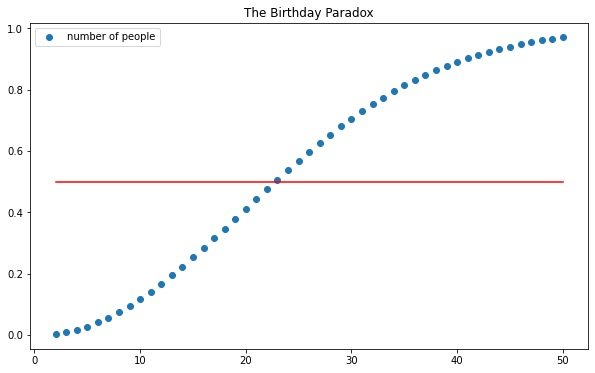

In [79]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(X, Y, label="number of people")
ax.plot(X, 49 * [0.5], 'r')
plt.title("The Birthday Paradox")
plt.legend();
# plt.savefig('birthday.png')

In [91]:
Y[20]

0.4747506462962858

In [90]:
Y[21]

0.5063230118194599

## `Numbers` Module

In [21]:
import numbers

## TutorialsPoint Python

In [3]:
class Employee:
    'Common base class for all employees'
    empCount = 0

    def __init__(self, name, salary):
        self.name = name
        self.salary = salary
        Employee.empCount += 1
   
    def displayCount(self):
        print("Total Employee %d" % Employee.empCount)

    def displayEmployee(self):
        print("Name : ", self.name,  ", Salary: ", self.salary)

"This would create first object of Employee class"
emp1 = Employee("Zara", 2000)
"This would create second object of Employee class"
emp2 = Employee("Manni", 5000)
emp1.displayEmployee()
emp2.displayEmployee()
print("Total Employee %d" % Employee.empCount)

Name :  Zara , Salary:  2000
Name :  Manni , Salary:  5000
Total Employee 2


In [4]:
emp1.empCount

2

In [10]:
getattr(emp1, "name"), hasattr(emp1, "name")

('Zara', True)

In [12]:
emp1.__dict__

{'name': 'Zara', 'salary': 2000}

In [13]:
emp1.__doc__

'Common base class for all employees'

In [14]:
emp1.__module__

'__main__'

In [20]:
Employee.__bases__

(object,)

In [17]:
Employee.__dict__

mappingproxy({'__module__': '__main__',
              '__doc__': 'Common base class for all employees',
              'empCount': 2,
              '__init__': <function __main__.Employee.__init__(self, name, salary)>,
              'displayCount': <function __main__.Employee.displayCount(self)>,
              'displayEmployee': <function __main__.Employee.displayEmployee(self)>,
              '__dict__': <attribute '__dict__' of 'Employee' objects>,
              '__weakref__': <attribute '__weakref__' of 'Employee' objects>})

In [18]:
Employee.__doc__

'Common base class for all employees'

In [22]:
Employee.__name__

'Employee'

In [3]:
import statsmodels.api as sm

In [4]:
sm.OLS

statsmodels.regression.linear_model.OLS

## Finding Pythagorean Triples

It's easy enough to find all the Pythagorean triples <$a$, $b$, $c$> for a given $a$. Since we have $a^2 + b^2 = c^2$ we must also have:

$$
a^2 = c^2 - b^2\\
a^2 = (c-b)(c+b)
$$

and so we simply need to analyze the prime factorization of $a$ in order to find triples. Note that $c-b$ and $c+b$ are integers if $b$ and $c$ are.

So let's start with $a=3$. Since $3^2 = 9$, the only possible values for c-b are 1, 3, and 9. But 3 and 9 are too big: Note that $b$ cannot be smaller than $a$, and as $b$ approaches $a$, the relevant right triangle approaches an isosceles one, which means that $c$ approaches $a\sqrt{2}$ and so $c-b$ approaches $a\sqrt{2} - a = a(\sqrt{2} - 1)$.

If we set $c-b$ to 1, then $c+b$ = 9 and so $b = \frac{c+b}{2} - \frac{c-b}{2} = 4$ and $c = \frac{c+b}{2} + \frac{c-b}{2} = 5$.

Let's see if we can write a function that will find _all_ such triples for a given $a$.

In [1]:
def pyth_triples_finder(a):
    import numpy as np
    
    # initialize list of triples
    triples = []
    
    # initialize c-b
    c_minus_b = int(a * (np.sqrt(2) - 1))

    while c_minus_b > 0:
        # update c+b
        c_plus_b = a**2 // c_minus_b
        
        if c_minus_b % 2 == c_plus_b % 2 and a**2 % c_minus_b == 0:
            triples.append((a, (c_plus_b - c_minus_b) // 2, (c_plus_b + c_minus_b) // 2))
        
        # update c_minus_b
        c_minus_b -= 1
    
    return triples

In [28]:
pyth_triples_finder(3)

[(3, 4, 5)]

In [29]:
pyth_triples_finder(4)

[]

In [30]:
pyth_triples_finder(20)

[(20, 21, 29), (20, 48, 52), (20, 99, 101)]

In [4]:
pyth_triples_finder(119)

[(119, 120, 169), (119, 408, 425), (119, 1008, 1015), (119, 7080, 7081)]

In [5]:
49/119

0.4117647058823529

In [31]:
pyth_triples_finder(400)

[(400, 420, 580),
 (400, 561, 689),
 (400, 750, 850),
 (400, 960, 1040),
 (400, 1218, 1282),
 (400, 1575, 1625),
 (400, 1980, 2020),
 (400, 2484, 2516),
 (400, 3990, 4010),
 (400, 4992, 5008),
 (400, 7995, 8005),
 (400, 9996, 10004),
 (400, 19998, 20002),
 (400, 39999, 40001)]

In [3]:
pyth_triples_finder(5040)

[(5040, 5292, 7308),
 (5040, 5500, 7460),
 (5040, 5655, 7575),
 (5040, 5775, 7665),
 (5040, 6156, 7956),
 (5040, 6318, 8082),
 (5040, 6486, 8214),
 (5040, 6720, 8400),
 (5040, 7030, 8650),
 (5040, 7138, 8738),
 (5040, 7316, 8884),
 (5040, 7644, 9156),
 (5040, 7905, 9375),
 (5040, 8100, 9540),
 (5040, 8372, 9772),
 (5040, 8733, 10083),
 (5040, 8778, 10122),
 (5040, 9152, 10448),
 (5040, 9450, 10710),
 (5040, 9984, 11184),
 (5040, 10212, 11388),
 (5040, 10449, 11601),
 (5040, 10633, 11767),
 (5040, 10780, 11900),
 (5040, 11220, 12300),
 (5040, 11571, 12621),
 (5040, 12096, 13104),
 (5040, 12470, 13450),
 (5040, 12750, 13710),
 (5040, 13662, 14562),
 (5040, 13727, 14623),
 (5040, 13959, 14841),
 (5040, 14268, 15132),
 (5040, 14700, 15540),
 (5040, 15275, 16085),
 (5040, 15476, 16276),
 (5040, 15808, 16592),
 (5040, 16422, 17178),
 (5040, 17280, 18000),
 (5040, 17794, 18494),
 (5040, 18564, 19236),
 (5040, 19276, 19924),
 (5040, 19525, 20165),
 (5040, 19845, 20475),
 (5040, 20868, 21468),


In [33]:
len(pyth_triples_finder(2520))

85

In [36]:
def pyth_triples_num(A):
    lens = []
    for j in range(1, A+1):
        lens.append(len(pyth_triples_finder(j)))
    return lens

In [38]:
pyth_triples_num(20)

[0, 0, 1, 0, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 3, 2, 1, 2, 1, 3]

In [3]:
def pyth_triples_finder_smallest_b(a):
    # This function assumes that there is at
    # least one triple with smallest member a.
    # Thus pyth_triples_finder_smallest_b(4)
    # will throw an error as will
    # pyth_triples_finder_smallest_b(n) for
    # n < 3.
    import numpy as np
    
    # initialize list of triples
    smallest = []
    
    # initialize c-b
    c_minus_b = int(a * (np.sqrt(2) - 1))

    while bool(smallest) == False:
        # update c+b
        c_plus_b = a**2 // c_minus_b
        
        if c_minus_b % 2 == c_plus_b % 2 and a**2 % c_minus_b == 0:
            smallest.append((a, (c_plus_b - c_minus_b) // 2, (c_plus_b + c_minus_b) // 2))
        
        # update c_minus_b
        c_minus_b -= 1
    
    return smallest

In [6]:
%time pyth_triples_finder_smallest_b(20)

CPU times: user 171 µs, sys: 2 µs, total: 173 µs
Wall time: 182 µs


[(20, 21, 29)]

In [7]:
%time pyth_triples_finder(20)

CPU times: user 183 µs, sys: 2 µs, total: 185 µs
Wall time: 194 µs


[(20, 21, 29), (20, 48, 52), (20, 99, 101)]

In [20]:
def find_smallest_ratio(n, N):
    smallest_ratios = []
    smallest = 2
    out_trip = (3, 4, 5)
    for j in range(n, N):
        smallest_trip = pyth_triples_finder_smallest_b(j)
        baratio = smallest_trip[0][1] / smallest_trip[0][0]
        if baratio < smallest:
            smallest = baratio
            out_trip = smallest_trip[0]
    return out_trip, smallest

In [21]:
find_smallest_ratio(5, 100)

((20, 21, 29), 1.05)

In [22]:
find_smallest_ratio(5, 200)

((119, 120, 169), 1.0084033613445378)

In [19]:
find_smallest_ratio(5, 20000)

((4059, 4060, 5741), 1.0002463661000247)

In [23]:
find_smallest_ratio(20000, 40000)

((23660, 23661, 33461), 1.0000422654268808)

In [24]:
find_smallest_ratio(40000, 50000)

((47320, 47322, 66922), 1.0000422654268808)

In [25]:
find_smallest_ratio(50000, 60000)

((59496, 59503, 84145), 1.0001176549684012)

In [26]:
find_smallest_ratio(60000, 70000)

((60885, 60900, 86115), 1.0002463661000247)